# Case Study Insights: Linear Models

**Docker image**: `ml4t`

**Purpose**: assemble the cross-case-study view of the linear family
(OLS, Ridge, Lasso, ElasticNet). Per-case-study deep dives live in
`case_studies/{cs}/13_model_analysis.py`; this notebook is the
comparative view across all nine case studies.

**Learning objectives**

- For each case study, read the highest-IC complete linear configuration's
  mean daily cross-sectional Spearman IC with its HAC interval on the primary label
- Compare regularization families (OLS, Ridge, Lasso, ElasticNet) at
  each case study's primary label
- Inspect per-fold IC distributions and the ICIR diagnostic for
  stability
- Extend the comparison across labels (horizon view) and across the
  classification ↔ regression metric symmetry
- Inspect coefficient sign consistency, Lasso sparsity, and the overlap
  of selected features across case studies

**Book reference**: Section 11.6 - Linear Models Across Nine Case Studies.

**Prerequisites**: each case study's `06_linear.py` pipeline has populated
`run_log/registry.db` for the linear family. Teaching notebooks NB01-NB06
cover the underlying techniques.

In [1]:
"""Case Study Insights: Linear - cross-case-study aggregation from the registry."""

import sqlite3
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# ml4t.diagnostic dlopens cudart; load torch first so its bundled CUDA
# runtime wins. Same precedence pattern as case_studies/utils/model_analysis.py.
import torch  # noqa: F401
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from sklearn.exceptions import InconsistentVersionWarning
from sklearn.metrics import roc_auc_score

from case_studies.research.population import retired_prediction_hashes
from case_studies.utils.analytics import (
    CASE_STUDY_IDS,
    PRIMARY_LABELS,
    SHORT_NAMES,
)
from case_studies.utils.insight_chapter import (
    plot_cross_cs_forest,
    plot_rolling_daily_ic,
)
from case_studies.utils.model_analysis import (
    load_predictions,
)
from utils.paths import get_case_study_dir
from utils.style import COLORS, show_with_alt

In [2]:
FAMILY = "linear"

## Complete-result guard

A model result is eligible for comparison only when no fold has an undefined
IC and its validation-day coverage equals the maximum for that label. The
local loader excludes predictions with any null fold IC and rejects shorter,
partially populated results before ranking.

In [3]:
METRICS_QUERY = """
    SELECT t.training_hash, t.family, t.config_name, t.label,
           p.prediction_hash, p.checkpoint_value, p.checkpoint_kind,
           pm.ic_mean, pm.ic_std, pm.ic_mean_daily, pm.ic_se_hac,
           pm.ic_ci_lo, pm.ic_ci_hi, pm.ic_t_hac, pm.ic_p_hac,
           pm.ic_n_days, pm.ic_hac_lag,
           (SELECT COUNT(*) FROM fold_metrics fm
            WHERE fm.prediction_hash = p.prediction_hash AND fm.ic IS NULL) AS n_null_folds
    FROM training_runs t
    JOIN prediction_sets p ON p.training_hash = t.training_hash
    JOIN prediction_metrics pm ON pm.prediction_hash = p.prediction_hash
    WHERE t.family = ? AND p.split = 'validation'
"""
FINITE_METRIC_FIELDS = [
    "ic_mean_daily",
    "ic_se_hac",
    "ic_ci_lo",
    "ic_ci_hi",
    "ic_t_hac",
    "ic_p_hac",
    "ic_n_days",
    "ic_hac_lag",
]

The loader preserves exact training and prediction identities so every later
statistic and coefficient view can be traced to one registry-selected artifact.

It also drops the generations a refit has retired. A case study that refits under
a corrected input artifact publishes new prediction identities and a snapshot that
supersedes the previous one; the retired rows stay in the registry, because the
record of what was superseded is evidence rather than litter. That record lives in
`official_populations`, one layer above the tables joined below, so a query that
stops at `prediction_metrics` sees two rows where the study has one. It cannot
separate them on the numbers either: a refit that changes only a declared input
leaves the computation, and therefore every metric, bit-identical, so a `max` or an
`ORDER BY created_at` would pick one arbitrarily and look like it had worked.

In [4]:
def load_complete_metrics(
    case_study: str,
    *,
    label: str | None = None,
) -> pl.DataFrame:
    """Load nondegenerate linear metrics with maximum coverage per label."""
    db_path = get_case_study_dir(case_study) / "run_log" / "registry.db"
    query = METRICS_QUERY
    params: list[str] = [FAMILY]
    if label is not None:
        query += " AND t.label = ?"
        params.append(label)
    with sqlite3.connect(f"file:{db_path}?mode=ro&immutable=1", uri=True) as connection:
        connection.row_factory = sqlite3.Row
        rows = [dict(row) for row in connection.execute(query, params).fetchall()]
        retired = retired_prediction_hashes(connection)
    if not rows:
        return pl.DataFrame()
    df = pl.DataFrame(rows, infer_schema_length=None)
    return (
        df.filter(
            ~pl.col("prediction_hash").is_in(list(retired))
            & (pl.col("n_null_folds") == 0)
            & pl.all_horizontal(
                pl.col(column).is_not_null() & pl.col(column).is_finite()
                for column in FINITE_METRIC_FIELDS
            )
        )
        .with_columns(_max_n_days=pl.col("ic_n_days").max().over("label"))
        .filter(pl.col("ic_n_days") == pl.col("_max_n_days"))
        .drop("_max_n_days", "n_null_folds")
    )

### Resolving a tie for rank one

Two rows can tie on mean daily IC for two different reasons, and only one of them is
an ambiguity. `config_name` alone does not identify a configuration: a name can be
reused across generations while the parameters behind it move, so collapsing two such
rows would pick one by hash order. A refit that only re-declared an input, on the other
hand, leaves the row bit-identical apart from its two hashes. Requiring agreement on
every column except those two hashes separates the duplicate from the genuine
ambiguity without reading the training spec here.

There is a third case, and it is the one this chapter is about. Ridge at a shrinkage
small enough to be numerically inert reproduces OLS, and the registry then holds two
or three rows whose every recorded statistic agrees to the last digit and whose only
difference is the name of the configuration. `crypto_perps_funding` at `fwd_ret_24h`
carries exactly that: `ols`, `ridge_a0.001` and `ridge_a0.01` at one IC, one standard
error and one day count. Nothing is ambiguous about the measurement, so the rows
collapse to the first name alphabetically and the others are carried in
`tied_configs` and printed, rather than the notebook refusing to draw the section. A
tie that differs on any measured column is still a real ambiguity and still raises.

The excluded set is written as "everything except the two identities a refit moves"
rather than as a list of fields to compare, because a list is a second copy of
`METRICS_QUERY` to keep in step: the first draft of one omitted `ic_mean` and
`ic_std` while claiming to cover every recorded statistic.

In [5]:
TIE_IDENTITY_EXCLUDED = frozenset({"training_hash", "prediction_hash"})
TIE_NAME_ONLY = frozenset({"config_name"})


def resolve_generation_tie(tied: pl.DataFrame, what: str) -> pl.DataFrame:
    """Collapse rows recording one measurement; raise when the tie is a real ambiguity.

    Adds `tied_configs`, which names the tied configurations when several of them were
    collapsed and is null otherwise.
    """
    no_tie = pl.lit(None, dtype=pl.Utf8).alias("tied_configs")
    if tied.height == 1:
        return tied.with_columns(no_tie)
    fields = [column for column in tied.columns if column not in TIE_IDENTITY_EXCLUDED]
    differing = [column for column in fields if tied[column].n_unique() > 1]
    names = sorted(tied["config_name"].unique().to_list()) if "config_name" in tied.columns else []
    if not differing:
        return tied.sort("prediction_hash").head(1).with_columns(no_tie)
    if set(differing) <= TIE_NAME_ONLY:
        return (
            tied.sort("config_name")
            .head(1)
            .with_columns(pl.lit(", ".join(names)).alias("tied_configs"))
        )
    raise RuntimeError(
        f"{what}: daily-IC rank one is ambiguous"
        + (f" between {', '.join(names)}" if names else "")
        + f"; the tied rows differ on {', '.join(differing)}"
    )


def report_name_only_ties(frame: pl.DataFrame, what: str) -> None:
    """Print the selections that were decided by name order because nothing else differed."""
    if "tied_configs" not in frame.columns:
        return
    ties = frame.filter(pl.col("tied_configs").is_not_null())
    if ties.is_empty():
        return
    print(f"{what}: tied on every recorded statistic, carried under the first name:")
    for row in ties.iter_rows(named=True):
        who = row.get("short_name") or row.get("case_study") or ""
        print(f"  {who} {row.get('label', '')}: {row['tied_configs']}")

The primary-label collector applies the same completeness rule independently
to every case study before selecting the highest mean daily IC.

In [6]:
def collect_complete_rank1(case_studies: list[str]) -> pl.DataFrame:
    """Return the highest-IC complete linear result per primary label."""
    frames = []
    for cs in case_studies:
        label = PRIMARY_LABELS[cs]
        df = load_complete_metrics(cs, label=label)
        if df.is_empty():
            raise RuntimeError(f"{cs}: no complete linear result for {label}")
        best_ic = df["ic_mean_daily"].max()
        winner = df.filter(pl.col("ic_mean_daily") == best_ic)
        # A tie between two generations of one configuration is a duplicate, not an ambiguity:
        # a refit writes a second prediction set under a new training hash with bit-identical
        # scores, and every fx_pairs linear configuration carries two such generations.
        winner = resolve_generation_tie(winner, f"{cs}: primary linear")
        frames.append(
            winner.with_columns(
                case_study=pl.lit(cs),
                short_name=pl.lit(SHORT_NAMES[cs]),
            )
        )
    if len(frames) != len(case_studies):
        raise RuntimeError("primary linear coverage is incomplete")
    return pl.concat(frames, how="diagonal_relaxed")

HAC inference is rebuilt from the exact selected prediction artifact. Daily
correlations are sorted before the Bartlett Newey-West calculation, avoiding
the fold-order dependence in several stored registry intervals.

In [7]:
def _daily_ic_values(row: dict, target_column: str | None = None) -> np.ndarray:
    """Load chronological daily IC values against an explicit artifact target."""
    parquet = (
        get_case_study_dir(row["case_study"])
        / "run_log"
        / "predictions"
        / row["prediction_hash"]
        / "predictions.parquet"
    )
    schema = pl.scan_parquet(parquet).collect_schema()
    score = "y_score" if "y_score" in schema else "prediction"
    actual = target_column or ("y_true" if "y_true" in schema else "actual")
    if actual not in schema:
        raise RuntimeError(
            f"{row['case_study']}: prediction artifact lacks target column {actual!r}"
        )
    daily = (
        pl.scan_parquet(parquet)
        .select("timestamp", score, actual)
        .group_by("timestamp")
        .agg(
            pl.corr(score, actual, method="spearman").alias("ic"),
            (pl.col(score).is_finite() & pl.col(actual).is_finite()).sum().alias("n_obs"),
        )
        .filter((pl.col("n_obs") >= 5) & pl.col("ic").is_finite())
        .sort("timestamp")
        .collect()
    )
    return daily["ic"].to_numpy()

In [8]:
def _bartlett_hac(values: np.ndarray, lag: int, case_study: str) -> dict[str, float]:
    """Return mean and Bartlett Newey-West inference for ordered observations."""
    n_days = len(values)
    if n_days < 3:
        raise RuntimeError(f"{case_study}: fewer than three daily IC observations")
    mean_ic = float(values.mean())
    residuals = values - mean_ic
    lag = min(lag, n_days - 1)
    long_run_sum = float(residuals @ residuals)
    for offset in range(1, lag + 1):
        weight = 1.0 - offset / (lag + 1.0)
        long_run_sum += 2.0 * weight * float(residuals[offset:] @ residuals[:-offset])
    variance = long_run_sum / n_days**2 * n_days / (n_days - 1)
    if variance < -1e-15:
        raise RuntimeError(f"{case_study}: negative HAC variance {variance}")
    variance = max(variance, 0.0)
    standard_error = float(np.sqrt(variance))
    if not np.isfinite(standard_error) or standard_error == 0.0:
        raise RuntimeError(f"{case_study}: degenerate HAC standard error")
    t_hac = mean_ic / standard_error
    critical = float(stats.t.ppf(0.975, n_days - 1))
    return {
        "ic_mean_daily": mean_ic,
        "ic_n_days": float(n_days),
        "ic_se_hac": standard_error,
        "ic_ci_lo": mean_ic - critical * standard_error,
        "ic_ci_hi": mean_ic + critical * standard_error,
        "ic_t_hac": t_hac,
        "ic_p_hac": float(2.0 * stats.t.sf(abs(t_hac), n_days - 1)),
        "ic_hac_lag": float(lag),
    }

In [9]:
def chronological_hac(row: dict, target_column: str | None = None) -> dict[str, float]:
    """Recompute daily IC and Bartlett Newey-West inference in time order."""
    values = _daily_ic_values(row, target_column=target_column)
    return _bartlett_hac(values, int(row["ic_hac_lag"]), row["case_study"])

Recomputed inference replaces only the selected rows, preserving their exact
training and prediction identities for later coefficient and fold diagnostics.

In [10]:
def replace_with_chronological_hac(
    selected: pl.DataFrame, target_column: str | None = None
) -> pl.DataFrame:
    """Bind selected rows to inference recomputed against an explicit target."""
    rows = []
    for row in selected.iter_rows(named=True):
        row.update(chronological_hac(row, target_column=target_column))
        rows.append(row)
    return pl.DataFrame(rows, infer_schema_length=None)

Every grouped comparison fails closed when two artifacts tie for the highest daily
IC, so row order never decides which configuration a section reports.

In [11]:
def select_unique_best(frame: pl.DataFrame, groups: list[str]) -> pl.DataFrame:
    """Select one highest daily-IC row in every requested group.

    Raises on a tie whose rows differ on anything measured, because row order must never
    decide which configuration a section reports. Two ties resolve instead, and neither is
    a judgement call: two generations of one configuration, where a refit wrote a second
    prediction set under a new training hash with bit-identical scores, and two or three
    configurations whose every recorded statistic agrees and which differ only in name.
    `resolve_generation_tie` names the second kind in `tied_configs`.
    """
    winners = []
    for group in frame.partition_by(groups, maintain_order=True):
        best_ic = group["ic_mean_daily"].max()
        best = group.filter(pl.col("ic_mean_daily") == best_ic)
        identity = {column: group[0, column] for column in groups}
        best = resolve_generation_tie(best, str(identity))
        winners.append(best)
    return pl.concat(winners, how="diagonal_relaxed") if winners else pl.DataFrame()

Fold diagnostics use the exact complete configurations selected above, rather
than independently ranking a second time.

In [12]:
def collect_selected_fold_ic(selected: pl.DataFrame) -> pl.DataFrame:
    """Load fold metrics for the exact primary-label selections."""
    frames = []
    for row in selected.iter_rows(named=True):
        db_path = get_case_study_dir(row["case_study"]) / "run_log" / "registry.db"
        with sqlite3.connect(f"file:{db_path}?mode=ro&immutable=1", uri=True) as connection:
            records = connection.execute(
                """
                SELECT fold_id, ic, ic_std, n_entities, rmse, mae
                FROM fold_metrics WHERE prediction_hash = ? ORDER BY fold_id
                """,
                (row["prediction_hash"],),
            ).fetchall()
        folds = pl.DataFrame(
            records,
            schema=["fold_id", "ic", "ic_std", "n_entities", "rmse", "mae"],
            orient="row",
        )
        if folds.is_empty() or folds["ic"].null_count() > 0:
            raise RuntimeError(f"{row['case_study']}: selected result has missing fold IC")
        frames.append(
            folds.with_columns(
                case_study=pl.lit(row["case_study"]),
                short_name=pl.lit(row["short_name"]),
            )
        )
    return pl.concat(frames, how="diagonal_relaxed") if frames else pl.DataFrame()

Multi-label comparisons repeat the complete-coverage selection within every
case-study and label pair.

In [13]:
def collect_complete_multi_label(
    case_studies: list[str],
    label_resolver,
) -> pl.DataFrame:
    """Return the highest-IC complete result for each requested label."""
    frames = []
    for cs in case_studies:
        for label in label_resolver(cs):
            df = load_complete_metrics(cs, label=label)
            if df.is_empty():
                continue
            winner = select_unique_best(df, ["label"])
            frames.append(
                winner.with_columns(
                    case_study=pl.lit(cs),
                    short_name=pl.lit(SHORT_NAMES[cs]),
                )
            )
    return pl.concat(frames, how="diagonal_relaxed") if frames else pl.DataFrame()

## 1. Scope and Coverage

The linear family is the baseline against which Ch12 (gradient boosting),
Ch13 (deep learning for time series), and Ch14 (latent factors) are
compared. Each case study's primary label is fixed in
`PRIMARY_LABELS`; the primary metric is mean daily cross-sectional Spearman IC.
Selection uses registry coverage and IC fields, while HAC inference is recomputed
from each selected prediction artifact after sorting daily IC chronologically.

In [14]:
coverage_rows = []
for cs in CASE_STUDY_IDS:
    primary = PRIMARY_LABELS[cs]
    df = load_complete_metrics(cs)
    if df.is_empty():
        coverage_rows.append(
            {
                "case_study": SHORT_NAMES[cs],
                "primary_label": primary,
                "n_labels": 0,
                "n_complete_configs_primary": 0,
            }
        )
        continue
    n_labels = df["label"].n_unique()
    n_configs_primary = df.filter(pl.col("label") == primary)["config_name"].n_unique()
    coverage_rows.append(
        {
            "case_study": SHORT_NAMES[cs],
            "primary_label": primary,
            "n_labels": n_labels,
            "n_complete_configs_primary": n_configs_primary,
        }
    )

coverage_df = pl.DataFrame(coverage_rows)
print("Complete linear coverage per case study (primary label and labels trained):")
coverage_df

Complete linear coverage per case study (primary label and labels trained):


case_study,primary_label,n_labels,n_complete_configs_primary
str,str,i64,i64
"""ETFs""","""fwd_ret_21d""",2,22
"""Crypto""","""fwd_ret_8h""",4,28
"""NQ100""","""fwd_ret_15m""",4,12
"""SP500 Eq+Opt""","""fwd_ret_5d""",5,28
"""US Firms""","""fwd_ret_1m""",3,28
"""FX""","""fwd_ret_1d""",3,28
"""CME Futures""","""fwd_ret_5d""",2,24
"""SP500 Options""","""ret_to_expiry""",1,28
"""US Equities""","""fwd_ret_1d""",1,12


## 2. Cross-CS Forest of Highest-IC Linear Configurations

For each case study, the linear configuration with the highest
mean daily IC on the primary label is plotted with its HAC interval.
Filled markers indicate $|t_{HAC}| > 2$ (CI excludes zero); open
markers indicate the CI overlaps zero.

In [15]:
rank1 = replace_with_chronological_hac(collect_complete_rank1(CASE_STUDY_IDS))
report_name_only_ties(rank1, "Primary label")
print(
    "Highest-IC complete linear configuration per case study "
    "(primary label, mean daily IC ± HAC 95 % CI):"
)
rank1.select(
    "short_name",
    "label",
    "config_name",
    pl.col("ic_mean_daily").round(4).alias("ic"),
    pl.col("ic_ci_lo").round(4).alias("ci_lo"),
    pl.col("ic_ci_hi").round(4).alias("ci_hi"),
    pl.col("ic_t_hac").round(2).alias("t_hac"),
    pl.col("ic_n_days").cast(pl.Int64).alias("n_days"),
)

Highest-IC complete linear configuration per case study (primary label, mean daily IC ± HAC 95 % CI):


short_name,label,config_name,ic,ci_lo,ci_hi,t_hac,n_days
str,str,str,f64,f64,f64,f64,i64
"""ETFs""","""fwd_ret_21d""","""ridge_a1000000.0""",0.0437,-0.0035,0.0909,1.81,1995
"""Crypto""","""fwd_ret_8h""","""ridge_a10000000.0""",0.0008,-0.0112,0.0127,0.12,2189
"""NQ100""","""fwd_ret_15m""","""ridge_a1000000.0""",0.0076,0.0049,0.0102,5.57,78812
"""SP500 Eq+Opt""","""fwd_ret_5d""","""lasso_f0.2""",-0.0009,-0.04,0.0382,-0.05,497
"""US Firms""","""fwd_ret_1m""","""lasso_f0.85""",-0.0036,-0.0259,0.0187,-0.32,110
"""FX""","""fwd_ret_1d""","""enet_f0.2""",0.003,-0.0136,0.0195,0.35,2063
"""CME Futures""","""fwd_ret_5d""","""enet_f0.5""",0.0037,-0.0302,0.0376,0.21,1285
"""SP500 Options""","""ret_to_expiry""","""ridge_a1000000.0""",-0.0027,-0.0328,0.0273,-0.18,478
"""US Equities""","""fwd_ret_1d""","""ridge_a1000000.0""",0.018,0.0145,0.0215,10.19,4031


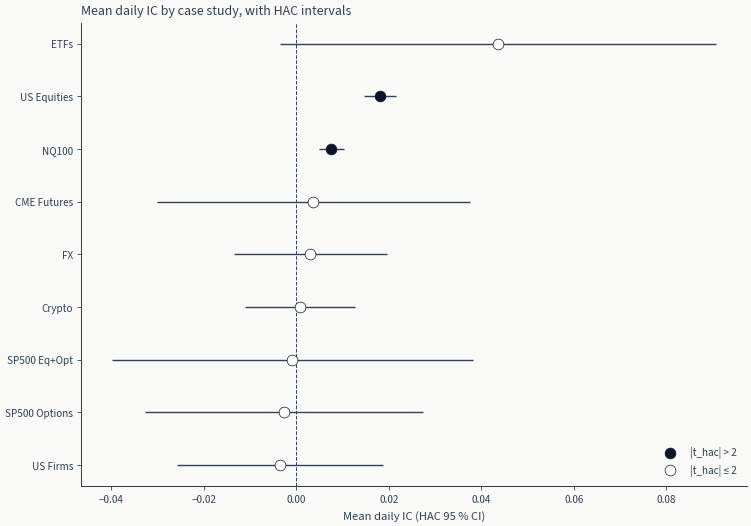

In [16]:
fig, ax = plot_cross_cs_forest(
    rank1,
    family=FAMILY,
    title="Mean daily IC by case study, with HAC intervals",
)
ax.set_xlabel("Mean daily IC (HAC 95 % CI)")
show_with_alt(
    fig,
    "Forest plot of mean daily information coefficient with HAC intervals, one row "
    "per case study on its primary label, against a vertical line at zero.",
)

In [17]:
significant = rank1.filter((pl.col("ic_ci_lo") > 0) | (pl.col("ic_ci_hi") < 0))
overlapping = rank1.filter(~((pl.col("ic_ci_lo") > 0) | (pl.col("ic_ci_hi") < 0)))
sig_names = ", ".join(significant.sort("short_name")["short_name"].to_list())
overlap_names = ", ".join(overlapping.sort("short_name")["short_name"].to_list())
display(
    Markdown(
        f"The HAC interval excludes zero for **{significant.height} of {rank1.height}** primary "
        f"labels ({sig_names}). It overlaps zero for {overlap_names}. The ETF result now selects "
        "the full-coverage Ridge fit; shorter or degenerate L1 fits are not eligible for this "
        "comparison. These are validation estimates read from the curated registries, not a new "
        "cross-case-study model selection exercise."
    )
)

The HAC interval excludes zero for **2 of 9** primary labels (NQ100, US Equities). It overlaps zero for CME Futures, Crypto, ETFs, FX, SP500 Eq+Opt, SP500 Options, US Firms. The ETF result now selects the full-coverage Ridge fit; shorter or degenerate L1 fits are not eligible for this comparison. These are validation estimates read from the curated registries, not a new cross-case-study model selection exercise.

## 3. Regularization Comparison

How much does the choice of regularization family change the IC at
the primary label? For each case study we take the highest-IC OLS,
Ridge, Lasso, and ElasticNet configurations and compare their daily-
mean daily IC with HAC intervals, then trace the Ridge regularization path
with its HAC band. The axes carry the confidence level.

In [18]:
def family_from_config(s: pl.Expr) -> pl.Expr:
    return (
        pl.when(s.str.starts_with("ols"))
        .then(pl.lit("ols"))
        .when(s.str.starts_with("ridge"))
        .then(pl.lit("ridge"))
        .when(s.str.starts_with("lasso"))
        .then(pl.lit("lasso"))
        .when(s.str.starts_with("enet"))
        .then(pl.lit("elastic_net"))
        .otherwise(pl.lit("other"))
    )

In [19]:
reg_rows = []
for cs in CASE_STUDY_IDS:
    primary = PRIMARY_LABELS[cs]
    df = load_complete_metrics(cs, label=primary)
    if df.is_empty():
        continue
    df = df.filter(pl.col("ic_mean_daily").is_not_null())
    df = df.with_columns(
        reg_family=family_from_config(pl.col("config_name")),
        short_name=pl.lit(SHORT_NAMES[cs]),
        case_study=pl.lit(cs),
    )
    reg_rows.append(df)

reg_df = pl.concat(reg_rows, how="diagonal_relaxed") if reg_rows else pl.DataFrame()

# Rank-1 per (CS, regularization family)
reg_best = replace_with_chronological_hac(
    select_unique_best(reg_df, ["case_study", "reg_family"])
).select(
    "case_study",
    "short_name",
    "reg_family",
    "config_name",
    "prediction_hash",
    "ic_mean_daily",
    "ic_ci_lo",
    "ic_ci_hi",
    "ic_t_hac",
)

# Wide pivot for table
ic_pivot = reg_best.pivot(on="reg_family", index="short_name", values="ic_mean_daily").sort(
    "short_name"
)
print("Mean daily IC by regularization family (complete primary-label results):")
ic_pivot

Mean daily IC by regularization family (complete primary-label results):


short_name,ols,ridge,lasso,elastic_net
str,f64,f64,f64,f64
"""CME Futures""",-0.023691,-0.004306,0.003672,0.003698
"""Crypto""",-0.008446,0.000757,-0.006602,-0.006701
"""ETFs""",0.035138,0.043668,0.037868,0.0379
"""FX""",-0.004822,0.00264,0.002931,0.002959
"""NQ100""",0.000774,0.007555,null,null
"""SP500 Eq+Opt""",-0.003862,-0.002974,-0.000905,-0.000907
"""SP500 Options""",-0.009166,-0.002714,-0.007943,-0.007746
"""US Equities""",0.015908,0.017989,null,null
"""US Firms""",-0.0048,-0.0048,-0.003594,-0.003595


### Figure: Regularization Family Comparison

Missing families remain gaps rather than zeros in the grouped chart.

In [20]:
def regularization_metric(
    frame: pl.DataFrame,
    case_studies: list[str],
    column: str,
) -> np.ndarray:
    """Align one regularization metric to the chart's case-study order."""
    lookup = dict(zip(frame["short_name"].to_list(), frame[column].to_list(), strict=True))
    return np.array([lookup.get(case_study, np.nan) for case_study in case_studies], dtype=float)

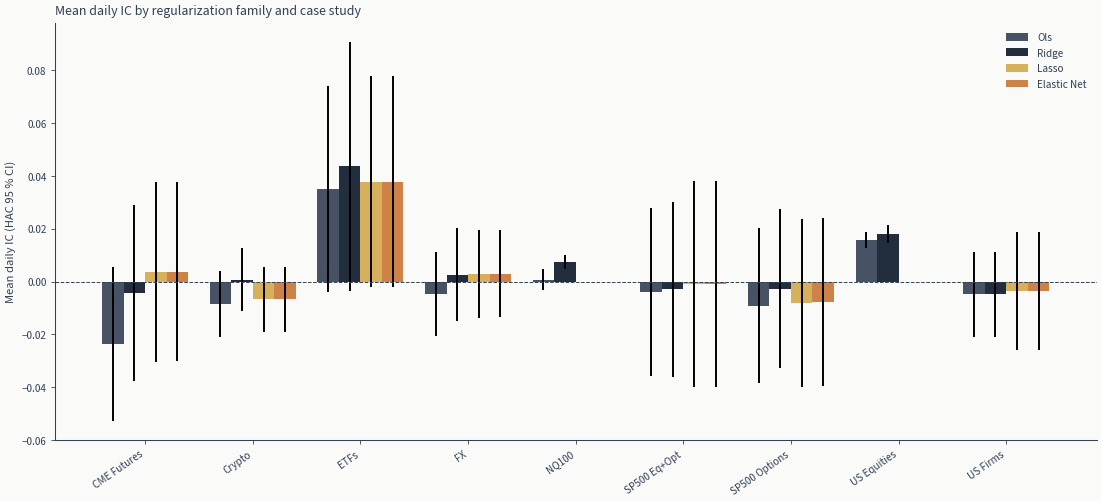

In [21]:
families_present = ["ols", "ridge", "lasso", "elastic_net"]
plot_data = reg_best.filter(pl.col("reg_family").is_in(families_present)).sort(
    ["short_name", "reg_family"]
)

fig, ax = plt.subplots(figsize=(11, 5))
cs_order = sorted(plot_data["short_name"].unique().to_list())
x = np.arange(len(cs_order))
width = 0.2
fam_colors = {
    "ols": COLORS["neutral"],
    "ridge": COLORS["blue"],
    "lasso": COLORS["amber"],
    "elastic_net": COLORS["copper"],
}

for i, fam in enumerate(families_present):
    sub = plot_data.filter(pl.col("reg_family") == fam)
    ic = regularization_metric(sub, cs_order, "ic_mean_daily")
    lo = regularization_metric(sub, cs_order, "ic_ci_lo")
    hi = regularization_metric(sub, cs_order, "ic_ci_hi")
    err = np.vstack([ic - lo, hi - ic])
    ax.bar(
        x + (i - 1.5) * width,
        ic,
        width=width,
        yerr=err,
        capsize=2,
        color=fam_colors[fam],
        alpha=0.9,
        label=fam.replace("_", " ").title(),
    )

ax.set_xticks(x)
ax.set_xticklabels(cs_order, rotation=35, ha="right")
ax.axhline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
ax.set_ylabel("Mean daily IC (HAC 95 % CI)")
ax.set_title("Mean daily IC by regularization family and case study")
ax.legend(frameon=False, fontsize=8, loc="best")
show_with_alt(
    fig,
    "Grouped bars of mean daily information coefficient by regularizer, one group per "
    "case study, with HAC error bars and a horizontal line at zero.",
)

In [22]:
ridge_ols = reg_best.filter(pl.col("reg_family").is_in(["ridge", "ols"]))
ridge_ols_wide = ridge_ols.pivot(
    on="reg_family", index="short_name", values="ic_mean_daily"
).drop_nulls(["ridge", "ols"])
ridge_wins = ridge_ols_wide.filter(pl.col("ridge") >= pl.col("ols")).height
l1_cases = reg_best.filter(pl.col("reg_family").is_in(["lasso", "elastic_net"]))[
    "short_name"
].n_unique()
display(
    Markdown(
        f"Ridge matches or exceeds OLS in **{ridge_wins} of {ridge_ols_wide.height}** comparable "
        f"case studies. Complete Lasso or ElasticNet results are available for {l1_cases} case "
        "studies. Most family-to-family point-estimate shifts remain smaller than the displayed "
        "uncertainty intervals, so regularization choice rarely changes the primary conclusion."
    )
)

Ridge matches or exceeds OLS in **9 of 9** comparable case studies. Complete Lasso or ElasticNet results are available for 7 case studies. Most family-to-family point-estimate shifts remain smaller than the displayed uncertainty intervals, so regularization choice rarely changes the primary conclusion.

### Ridge regularization path

How does mean daily IC change as Ridge $\alpha$ increases? A flat
path means the conditioning of the feature matrix is already benign;
a pronounced peak indicates an optimal shrinkage strength.

In [23]:
ridge_path = replace_with_chronological_hac(
    reg_df.filter(pl.col("reg_family") == "ridge")
    .with_columns(
        alpha=pl.col("config_name").str.extract(r"ridge_a([\d.e+]+)", 1).cast(pl.Float64),
    )
    .filter(pl.col("alpha").is_not_null())
    .sort(["case_study", "alpha"])
)

palette = [
    COLORS["blue"],
    COLORS["copper"],
    COLORS["amber"],
    COLORS["positive"],
    COLORS["negative"],
    COLORS["slate"],
    COLORS["amber_light"],
    COLORS["neutral"],
    COLORS["blue_light"],
]
ridge_markers = ["o", "s", "D", "^", "v", "P", "X", "*", "h"]
ridge_styles = ["-", "--", "-.", ":", "-", "--", "-.", ":", "-"]

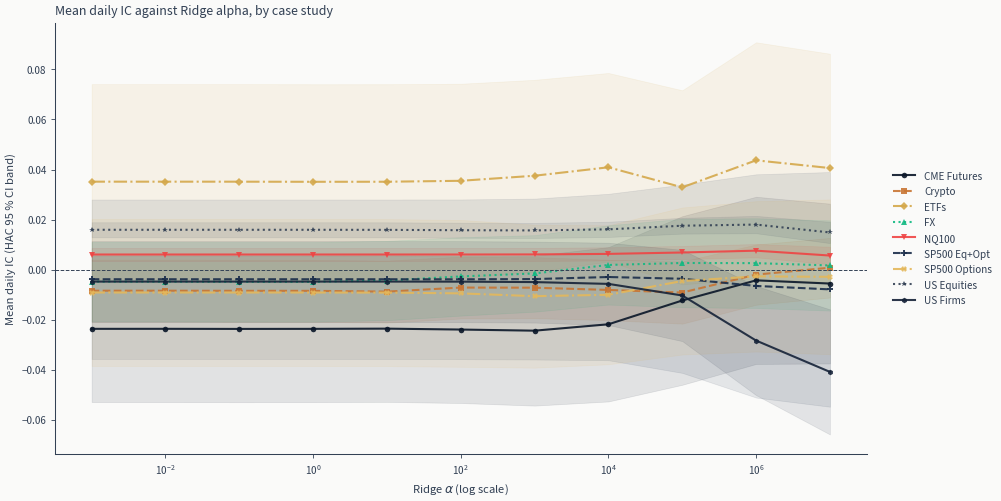

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
cs_list_sorted = sorted(ridge_path["case_study"].unique().to_list())
for i, cs in enumerate(cs_list_sorted):
    sub = ridge_path.filter(pl.col("case_study") == cs).sort("alpha")
    if sub.height < 2:
        continue
    a = sub["alpha"].to_numpy()
    ic = sub["ic_mean_daily"].to_numpy()
    lo = sub["ic_ci_lo"].to_numpy()
    hi = sub["ic_ci_hi"].to_numpy()
    color = palette[i % len(palette)]
    name = SHORT_NAMES.get(cs, cs)
    ax.fill_between(a, lo, hi, color=color, alpha=0.10)
    ax.plot(
        a,
        ic,
        marker=ridge_markers[i],
        linestyle=ridge_styles[i],
        color=color,
        label=name,
        linewidth=1.5,
        markersize=4,
        alpha=0.9,
    )

ax.set_xscale("log")
ax.set_xlabel(r"Ridge $\alpha$ (log scale)")
ax.set_ylabel("Mean daily IC (HAC 95 % CI band)")
ax.axhline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
ax.set_title("Mean daily IC against Ridge alpha, by case study")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)
show_with_alt(
    fig,
    "Mean daily information coefficient against Ridge alpha on a log axis, one line per "
    "case study with a shaded HAC band, against a horizontal line at zero.",
)

The confidence bands put the path curvature in context. An apparent optimum
matters only when its change is large relative to uncertainty; across these
panels, most neighboring Ridge settings remain statistically difficult to
distinguish.

## 4. Persistence and Stability

A positive mean daily IC averaged over the whole validation period can
still come from a few good stretches. The primary persistence view is a
three-month rolling mean of the daily IC, which traces how ranking quality
evolves over time. Because case studies cover different validation windows,
the comparison is clipped to the common validation period for ETFs and FX.
(Figure 11.8 in the chapter.) Per-fold IC and ICIR below are secondary stability
diagnostics.

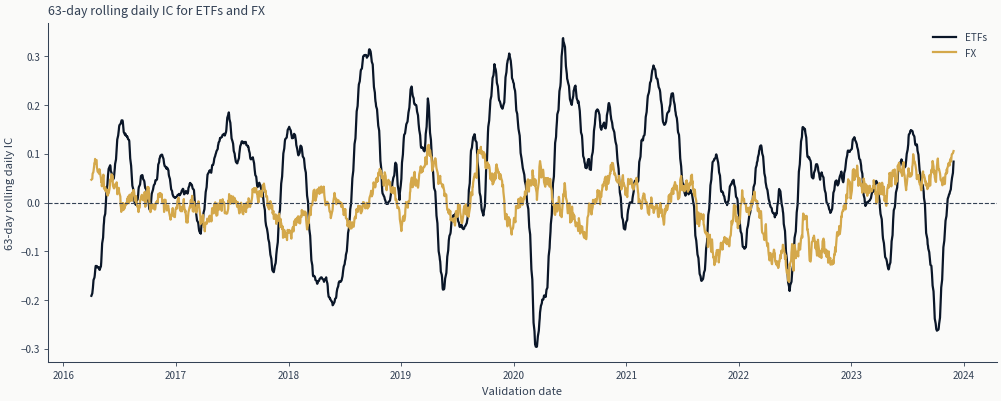

In [25]:
fig, _ = plot_rolling_daily_ic(
    ["etfs", "fx_pairs"],
    window=63,
    common_window=True,
    selected_prediction_hashes={
        row["case_study"]: row["prediction_hash"]
        for row in rank1.filter(pl.col("case_study").is_in(["etfs", "fx_pairs"])).iter_rows(
            named=True
        )
    },
    title="63-day rolling daily IC for ETFs and FX",
)
show_with_alt(
    fig,
    "Rolling 63-day information coefficient for the ETF and FX selected fits over their "
    "shared window, against a horizontal line at zero.",
)

The rolling view tests whether a full-period average is broadly persistent or
concentrated in a few stretches. Both paths cross zero here, so neither
full-period average describes every validation regime. Both are validation
estimates: the holdout period is untouched by this chapter.

In [26]:
fold_df = collect_selected_fold_ic(rank1)
fold_summary = (
    fold_df.group_by(["case_study", "short_name"])
    .agg(
        n_folds=pl.col("ic").count(),
        mean=pl.col("ic").mean(),
        median=pl.col("ic").median(),
        std=pl.col("ic").std(),
        pct_positive=(pl.col("ic") > 0).mean(),
    )
    .sort("median", descending=True)
)
print("Per-fold IC summary for the highest-IC linear config (primary label):")
fold_summary

Per-fold IC summary for the highest-IC linear config (primary label):


case_study,short_name,n_folds,mean,median,std,pct_positive
str,str,u32,f64,f64,f64,f64
"""etfs""","""ETFs""",8,0.043417,0.033715,0.040993,0.875
"""us_equities_panel""","""US Equities""",16,0.017988,0.015742,0.009984,1.0
"""nasdaq100_microstructure""","""NQ100""",2,0.007555,0.007555,0.001004,1.0
"""fx_pairs""","""FX""",8,0.002989,0.005933,0.038898,0.5
"""crypto_perps_funding""","""Crypto""",2,0.000753,0.000753,0.011107,0.5
"""us_firm_characteristics""","""US Firms""",10,-0.003594,-0.000574,0.032559,0.3
"""sp500_equity_option_analytics""","""SP500 Eq+Opt""",2,-0.001047,-0.001047,0.019952,0.5
"""sp500_options""","""SP500 Options""",2,-0.002263,-0.002263,0.012698,0.5
"""cme_futures""","""CME Futures""",5,0.003489,-0.031211,0.065564,0.4


### Figure: Per-Fold IC Distribution

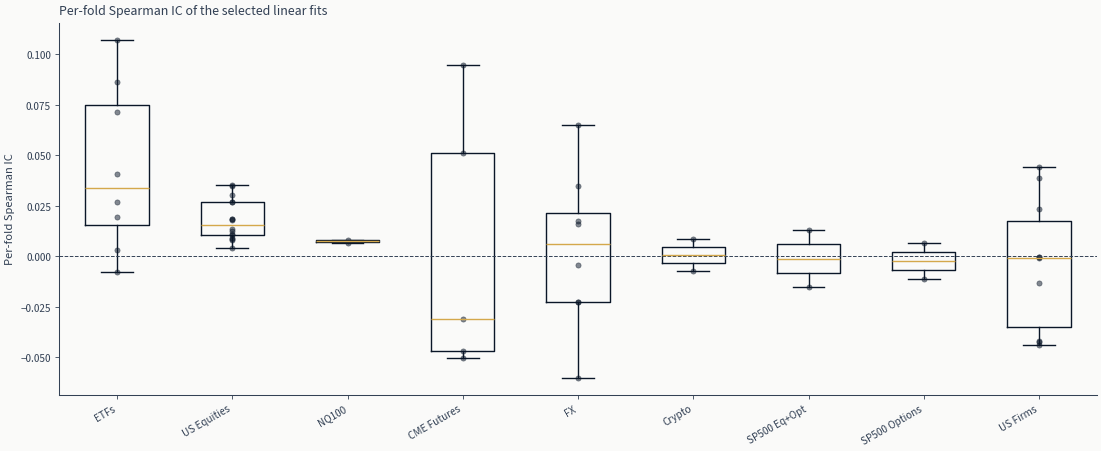

In [27]:
order = rank1.sort("ic_mean_daily", descending=True)["short_name"].to_list()
present = [c for c in order if c in fold_df["short_name"].unique().to_list()]

fig, ax = plt.subplots(figsize=(11, 4.5))
data = [fold_df.filter(pl.col("short_name") == cs)["ic"].to_numpy() for cs in present]
positions = np.arange(len(present))
ax.boxplot(data, positions=positions, widths=0.55, showfliers=True)
for i, arr in enumerate(data):
    if len(arr):
        ax.scatter(np.full(len(arr), i), arr, alpha=0.5, s=14, color=COLORS["blue"])
ax.axhline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
ax.set_xticks(positions)
ax.set_xticklabels(present, rotation=30, ha="right")
ax.set_ylabel("Per-fold Spearman IC")
ax.set_title("Per-fold Spearman IC of the selected linear fits")
show_with_alt(
    fig,
    "Box plots of per-fold Spearman information coefficient, one box per case study with "
    "the individual folds overlaid as points, against a horizontal line at zero.",
)

In [28]:
most_positive = fold_summary.sort("pct_positive", descending=True).row(0, named=True)
least_variable = fold_summary.sort("std").row(0, named=True)
display(
    Markdown(
        f"**{most_positive['short_name']}** has the largest positive-fold share "
        f"({most_positive['pct_positive']:.0%}), while **{least_variable['short_name']}** has the "
        f"smallest fold-level standard deviation ({least_variable['std']:.4f}). Fold counts range "
        f"from {fold_summary['n_folds'].min()} to {fold_summary['n_folds'].max()}, so the boxplots "
        "are stability diagnostics rather than equal-precision estimates."
    )
)

**US Equities** has the largest positive-fold share (100%), while **NQ100** has the smallest fold-level standard deviation (0.0010). Fold counts range from 2 to 16, so the boxplots are stability diagnostics rather than equal-precision estimates.

### ICIR cross-CS bar

The information ratio $\text{ICIR} = |\overline{\text{IC}}| / \sigma(\text{IC})$
is a stability-adjusted signal-strength summary. With only a handful of folds per
case study it is sample-starved and should be read alongside the
mean daily IC and per-fold distribution, not as a standalone score.

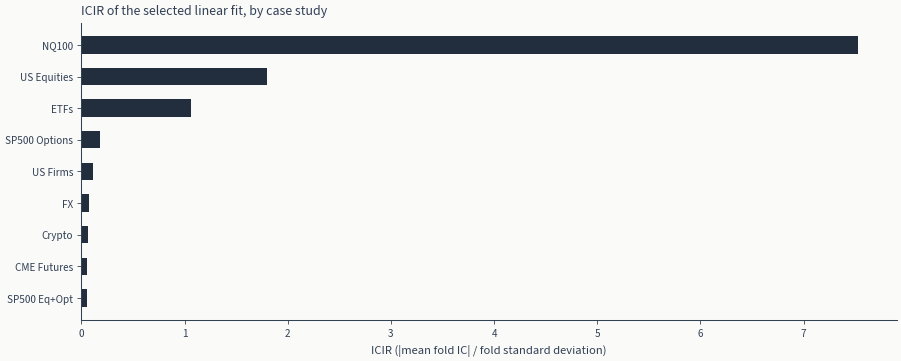

In [29]:
icir = fold_summary.with_columns(icir=(pl.col("mean").abs() / pl.col("std")).round(3)).sort(
    "icir", descending=True, nulls_last=True
)

fig, ax = plt.subplots(figsize=(9, 3.6))
y = np.arange(icir.height)
ax.barh(y, icir["icir"].to_numpy(), color=COLORS["blue"], alpha=0.9, height=0.55)
ax.set_yticks(y)
ax.set_yticklabels(icir["short_name"].to_list())
ax.invert_yaxis()
ax.set_xlabel("ICIR (|mean fold IC| / fold standard deviation)")
ax.set_title("ICIR of the selected linear fit, by case study")
show_with_alt(
    fig,
    "Horizontal bars of ICIR, the absolute mean fold information coefficient divided by "
    "its fold standard deviation, one bar per case study.",
)

In [30]:
icir_leader = icir.row(0, named=True)
display(
    Markdown(
        f"**{icir_leader['short_name']}** has the largest fold ICIR "
        f"({icir_leader['icir']:.3f}). With only "
        f"{icir_leader['n_folds']} folds for that estimate, ICIR remains a descriptive "
        "stability diagnostic and does not replace the daily HAC interval."
    )
)

**NQ100** has the largest fold ICIR (7.525). With only 2 folds for that estimate, ICIR remains a descriptive stability diagnostic and does not replace the daily HAC interval.

## 5. Multi-Label Horizon and Metric Symmetry

### 5a. Linear IC across regression labels per case study

Several case studies trained the linear pipeline on multiple regression
horizons. For each (case study, label), we take the highest complete
mean daily IC across linear configurations and compare across horizons -
this diagnoses whether the cross-sectional signal strengthens or
weakens with the prediction window.

In [31]:
def regression_labels(cs: str) -> list[str]:
    df = load_complete_metrics(cs)
    if df.is_empty():
        return []
    return [
        lbl
        for lbl in df["label"].unique().to_list()
        if lbl is not None
        and lbl.startswith("fwd_ret_")
        and "spot" not in lbl
        and "_win" not in lbl
        and "risk_adj" not in lbl
    ]


horizon_df = replace_with_chronological_hac(
    collect_complete_multi_label(CASE_STUDY_IDS, regression_labels)
)
report_name_only_ties(horizon_df, "Regression labels")
print(
    f"Highest-IC complete linear configuration per (case study, regression label): "
    f"{horizon_df.height} rows"
)
horizon_df.select(
    "short_name",
    "label",
    pl.col("ic_mean_daily").round(4).alias("ic"),
    pl.col("ic_ci_lo").round(4).alias("ci_lo"),
    pl.col("ic_ci_hi").round(4).alias("ci_hi"),
    pl.col("ic_t_hac").round(2).alias("t_hac"),
)

Regression labels: tied on every recorded statistic, carried under the first name:
  Crypto fwd_ret_24h: ols, ridge_a0.001, ridge_a0.01
Highest-IC complete linear configuration per (case study, regression label): 16 rows


short_name,label,ic,ci_lo,ci_hi,t_hac
str,str,f64,f64,f64,f64
"""ETFs""","""fwd_ret_5d""",0.025,-0.0012,0.0512,1.87
"""ETFs""","""fwd_ret_21d""",0.0437,-0.0035,0.0909,1.81
"""Crypto""","""fwd_ret_8h""",0.0008,-0.0112,0.0127,0.12
"""Crypto""","""fwd_ret_24h""",-0.0126,-0.0295,0.0042,-1.47
"""NQ100""","""fwd_ret_5m""",0.0117,0.0102,0.0131,15.71
…,…,…,…,…,…
"""FX""","""fwd_ret_1d""",0.003,-0.0136,0.0195,0.35
"""FX""","""fwd_ret_21d""",0.0086,-0.0488,0.066,0.29
"""CME Futures""","""fwd_ret_21d""",0.0435,-0.0292,0.1161,1.17


In [32]:
HORIZON_DAYS = {
    "fwd_ret_5m": 5 / (6.5 * 60),
    "fwd_ret_15m": 15 / (6.5 * 60),
    "fwd_ret_60m": 60 / (6.5 * 60),
    "fwd_ret_8h": 1.0 / 3,
    "fwd_ret_24h": 1.0,
    "fwd_ret_1d": 1.0,
    "fwd_ret_5d": 5.0,
    "fwd_ret_10d": 10.0,
    "fwd_ret_21d": 21.0,
    "fwd_ret_1m": 21.0,
    "fwd_ret_3m": 63.0,
    "fwd_ret_1m_win": 21.0,
    "fwd_ret_risk_adj_5d": 5.0,
}

plot_horizon = horizon_df.with_columns(
    horizon_days=pl.col("label").replace_strict(HORIZON_DAYS, default=None).cast(pl.Float64),
).filter(pl.col("horizon_days").is_not_null())

multi_cs = (
    plot_horizon.group_by("short_name").len().filter(pl.col("len") >= 2)["short_name"].to_list()
)
plot_horizon = plot_horizon.filter(pl.col("short_name").is_in(multi_cs))

In [33]:
if plot_horizon.height > 0:
    palette = [
        COLORS["blue"],
        COLORS["copper"],
        COLORS["amber"],
        COLORS["positive"],
        COLORS["negative"],
        COLORS["slate"],
        COLORS["amber_light"],
        COLORS["neutral"],
    ]

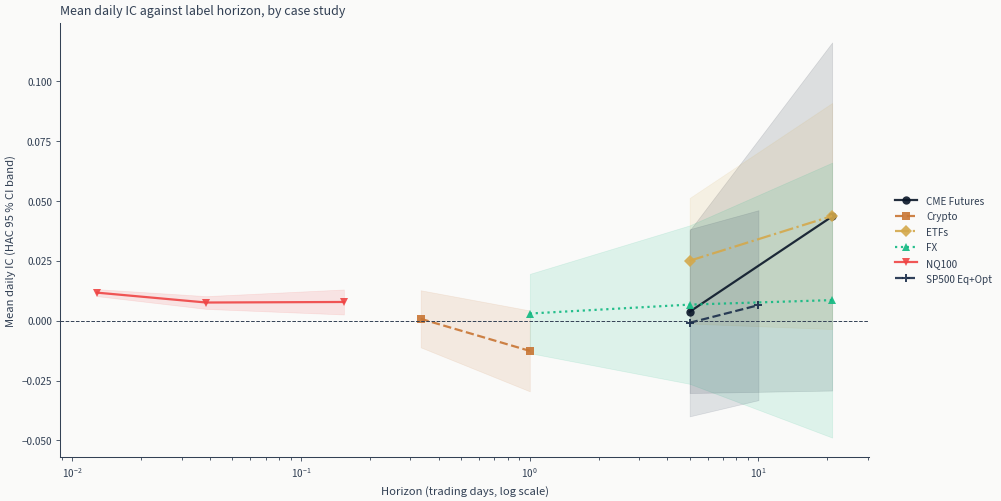

In [34]:
if plot_horizon.height > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    cs_sorted = sorted(plot_horizon["short_name"].unique().to_list())
    markers = ["o", "s", "D", "^", "v", "P", "X", "*"]
    linestyles = ["-", "--", "-.", ":", "-", "--", "-.", ":"]
    for idx, cs in enumerate(cs_sorted):
        sub = plot_horizon.filter(pl.col("short_name") == cs).sort("horizon_days")
        if sub.height < 2:
            continue
        x = sub["horizon_days"].to_numpy()
        ic = sub["ic_mean_daily"].to_numpy()
        lo = sub["ic_ci_lo"].to_numpy()
        hi = sub["ic_ci_hi"].to_numpy()
        color = palette[idx % len(palette)]
        ax.fill_between(x, lo, hi, color=color, alpha=0.12)
        ax.plot(
            x,
            ic,
            marker=markers[idx % len(markers)],
            linestyle=linestyles[idx % len(linestyles)],
            color=color,
            label=cs,
            linewidth=1.6,
            markersize=6,
            alpha=0.9,
        )
    ax.set_xscale("log")
    ax.set_xlabel("Horizon (trading days, log scale)")
    ax.set_ylabel("Mean daily IC (HAC 95 % CI band)")
    ax.axhline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
    ax.set_title("Mean daily IC against label horizon, by case study")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)
    show_with_alt(
        fig,
        "Mean daily information coefficient against label horizon in trading days on a log "
        "axis, one line per case study with a shaded HAC band, against a horizontal line at "
        "zero.",
    )

In [35]:
display(
    Markdown(
        f"The horizon view covers **{plot_horizon['short_name'].n_unique()}** case studies with "
        "at least two comparable regression labels. Direction and magnitude vary by panel, and "
        "the HAC bands show that many within-panel orderings remain uncertain. Each horizon is a "
        "separate estimand; the chart does not treat a longer horizon as more observations."
    )
)

The horizon view covers **6** case studies with at least two comparable regression labels. Direction and magnitude vary by panel, and the HAC bands show that many within-panel orderings remain uncertain. Each horizon is a separate estimand; the chart does not treat a longer horizon as more observations.

### 5b. Classification ↔ regression metric symmetry

A linear model trained on a continuous return label has a regression
score; the same modelling apparatus can be trained on the binary
direction label of the same horizon. Across the case studies that
carry binary direction labels, two questions are symmetric:

- **Direction A** - the classification model's score, evaluated as
  IC against the *continuous* return, asks whether the directional
  classifier is also a useful *cross-sectional ranker*. This number
  is on the registry as `prediction_metrics.ic_mean_daily` for
  `task_type='classification'` rows.
- **Direction B** - the regression model's score, evaluated as mean daily AUC
  against the *binary* direction, asks whether the continuous
  regression score is also a useful *cross-sectional binary classifier*. This number
  is computed on the fly here from raw OOF predictions, since the
  registry stores AUC only for classification training runs.

We restrict to case studies with a binary direction label paired to a
regression label for the same horizon; ternary direction labels (e.g.
NASDAQ-100 `fwd_dir_15m`, Crypto `fwd_dir_8h_3c`) need a multi-class
AUC and are out of scope for this brief subsection.

In [36]:
SYMMETRY_PAIRS: dict[str, list[tuple[str, str]]] = {
    # cs -> [(regression_label, binary_direction_label), ...]
    "crypto_perps_funding": [("fwd_ret_8h", "fwd_dir_8h")],
    "sp500_equity_option_analytics": [
        ("fwd_ret_5d", "fwd_dir_5d"),
        ("fwd_ret_10d", "fwd_dir_10d"),
    ],
    "us_firm_characteristics": [("fwd_ret_1m", "fwd_class_1m")],
}

In [37]:
def _load_binary_label(cs: str, dir_label: str) -> pl.DataFrame:
    """Load one canonical binary direction label surface."""
    p = get_case_study_dir(cs) / "labels" / f"{dir_label}.parquet"
    if not p.exists():
        return pl.DataFrame()
    df = pl.read_parquet(p)
    return df.rename({dir_label: "y_dir"}).select("timestamp", "symbol", "y_dir")

In [38]:
def _aligned_direction_scores(cs: str, reg_label: str, dir_label: str, best: dict) -> pl.DataFrame:
    """Join one exact regression prediction artifact to its binary labels."""
    preds = load_predictions(
        cs,
        family=FAMILY,
        label=reg_label,
        config_name=best["config_name"],
        checkpoint_value=best["checkpoint_value"],
        split="validation",
    )
    if preds.height == 0:
        return pl.DataFrame()
    preds = preds.filter(pl.col("prediction_hash") == best["prediction_hash"])
    if preds.is_empty():
        raise RuntimeError(f"{cs}: selected regression prediction artifact is missing")
    dir_df = _load_binary_label(cs, dir_label)
    if dir_df.is_empty():
        return pl.DataFrame()

    # Align timestamp + symbol dtypes for the join.
    if preds["timestamp"].dtype != dir_df["timestamp"].dtype:
        preds = preds.with_columns(pl.col("timestamp").cast(pl.Datetime("ms")))
        dir_df = dir_df.with_columns(pl.col("timestamp").cast(pl.Datetime("ms")))
    if preds["symbol"].dtype != dir_df["symbol"].dtype:
        preds = preds.with_columns(pl.col("symbol").cast(pl.Utf8))
        dir_df = dir_df.with_columns(pl.col("symbol").cast(pl.Utf8))

    return preds.join(dir_df, on=["timestamp", "symbol"], how="inner").filter(
        pl.col("y_dir").is_in([0, 1]) & pl.col("y_score").is_not_null()
    )

In [39]:
def _mean_daily_auc(merged: pl.DataFrame) -> tuple[float, int] | None:
    """Compute unweighted mean daily AUC on dates containing both classes."""
    if merged.height == 0 or merged["y_dir"].n_unique() < 2:
        return None
    daily_auc = []
    for group in merged.sort("timestamp").partition_by("timestamp", maintain_order=True):
        if group["y_dir"].n_unique() < 2:
            continue
        daily_auc.append(roc_auc_score(group["y_dir"].to_numpy(), group["y_score"].to_numpy()))
    if not daily_auc:
        return None
    return float(np.mean(daily_auc)), len(daily_auc)

In [40]:
def _direction_b_auc(cs: str, reg_label: str, dir_label: str) -> dict | None:
    """Highest-IC complete regression config to mean daily binary AUC."""
    reg_metrics = load_complete_metrics(cs, label=reg_label)
    if reg_metrics.is_empty():
        return None
    best = select_unique_best(reg_metrics, ["label"]).row(0, named=True)
    merged = _aligned_direction_scores(cs, reg_label, dir_label, best)
    auc_result = _mean_daily_auc(merged)
    if auc_result is None:
        return None
    auc, n_days = auc_result
    return {
        "case_study": cs,
        "short_name": SHORT_NAMES[cs],
        "reg_label": reg_label,
        "dir_label": dir_label,
        "reg_config": best["config_name"],
        "reg_ic_mean_daily": best["ic_mean_daily"],
        "reg_score_auc": auc,
        "n": merged.height,
        "n_days": n_days,
    }

In [41]:
sym_rows = []
for cs, pairs in SYMMETRY_PAIRS.items():
    for reg_lbl, dir_lbl in pairs:
        # Direction A: classification model score to IC vs continuous return
        cls_metrics = load_complete_metrics(cs, label=dir_lbl)
        cls_ic = cls_ic_lo = cls_ic_hi = cls_t = None
        cls_config = None
        if not cls_metrics.is_empty():
            cls_metrics = cls_metrics.filter(pl.col("ic_mean_daily").is_not_null())
            if not cls_metrics.is_empty():
                selected_cls = select_unique_best(cls_metrics, ["label"]).with_columns(
                    case_study=pl.lit(cs)
                )
                top = replace_with_chronological_hac(selected_cls, target_column="eval_actual").row(
                    0, named=True
                )
                cls_ic = top["ic_mean_daily"]
                cls_ic_lo = top.get("ic_ci_lo")
                cls_ic_hi = top.get("ic_ci_hi")
                cls_t = top.get("ic_t_hac")
                cls_config = top["config_name"]
        # Direction B: regression model score to AUC vs binary direction
        b = _direction_b_auc(cs, reg_lbl, dir_lbl)
        sym_rows.append(
            {
                "short_name": SHORT_NAMES[cs],
                "reg_label": reg_lbl,
                "dir_label": dir_lbl,
                "cls_config": cls_config,
                "cls_score_ic": cls_ic,
                "cls_score_ic_lo": cls_ic_lo,
                "cls_score_ic_hi": cls_ic_hi,
                "cls_score_ic_t": cls_t,
                "reg_config": (b or {}).get("reg_config"),
                "reg_score_auc": (b or {}).get("reg_score_auc"),
                "n_b": (b or {}).get("n"),
                "n_b_days": (b or {}).get("n_days"),
            }
        )

In [42]:
sym_df = pl.DataFrame(
    sym_rows,
    schema_overrides={
        "cls_score_ic": pl.Float64,
        "cls_score_ic_lo": pl.Float64,
        "cls_score_ic_hi": pl.Float64,
        "cls_score_ic_t": pl.Float64,
        "reg_score_auc": pl.Float64,
        "n_b": pl.Int64,
        "n_b_days": pl.Int64,
    },
)
print("Direction A (classification score to IC) and Direction B (regression score to AUC):")
sym_df.select(
    "short_name",
    "reg_label",
    "dir_label",
    pl.col("cls_score_ic").round(4).alias("A_ic"),
    pl.col("cls_score_ic_lo").round(4).alias("A_lo"),
    pl.col("cls_score_ic_hi").round(4).alias("A_hi"),
    pl.col("cls_score_ic_t").round(2).alias("A_t"),
    pl.col("reg_score_auc").round(4).alias("B_auc"),
    "n_b_days",
)

Direction A (classification score to IC) and Direction B (regression score to AUC):


short_name,reg_label,dir_label,A_ic,A_lo,A_hi,A_t,B_auc,n_b_days
str,str,str,f64,f64,f64,f64,f64,i64
"""Crypto""","""fwd_ret_8h""","""fwd_dir_8h""",0.0328,0.0212,0.0444,5.55,0.5009,1649
"""SP500 Eq+Opt""","""fwd_ret_5d""","""fwd_dir_5d""",0.0053,-0.0283,0.0389,0.31,0.507,497
"""SP500 Eq+Opt""","""fwd_ret_10d""","""fwd_dir_10d""",0.0031,-0.0416,0.0478,0.14,0.506,492
"""US Firms""","""fwd_ret_1m""","""fwd_class_1m""",0.0744,0.0479,0.1009,5.57,0.4962,110


### Figure: Direction A and Direction B side by side

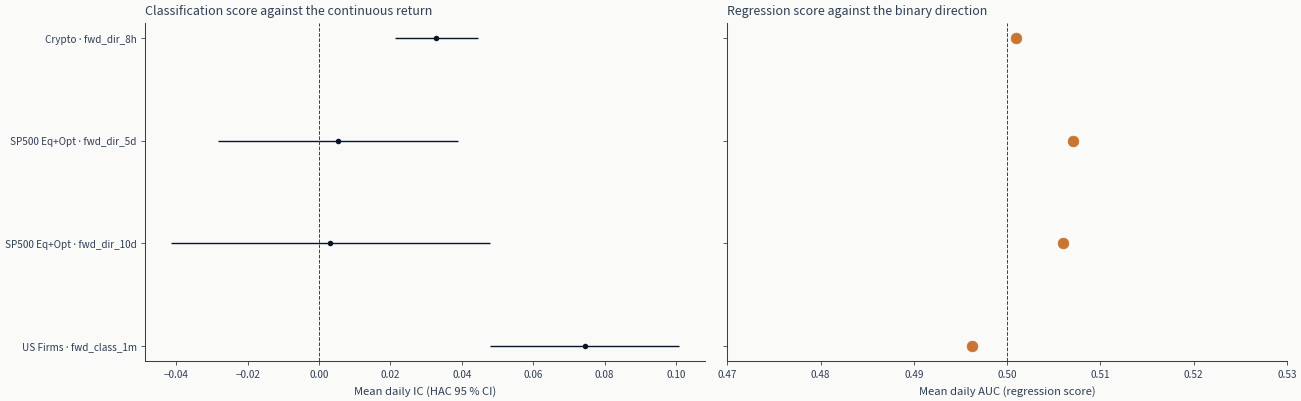

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
labels_y = [f"{r['short_name']} · {r['dir_label']}" for r in sym_df.iter_rows(named=True)]
y = np.arange(sym_df.height)

# Panel (a): Direction A, classification score IC vs continuous return
ax = axes[0]
ic = sym_df["cls_score_ic"].to_numpy()
lo = sym_df["cls_score_ic_lo"].to_numpy()
hi = sym_df["cls_score_ic_hi"].to_numpy()
ax.errorbar(
    ic,
    y,
    xerr=[ic - lo, hi - ic],
    fmt="o",
    color=COLORS["blue"],
    capsize=3,
    lw=1,
)
ax.axvline(0, color=COLORS["neutral"], lw=0.7, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(labels_y)
ax.invert_yaxis()
ax.set_xlabel("Mean daily IC (HAC 95 % CI)")
ax.set_title("Classification score against the continuous return")

# Panel (b): Direction B, regression score AUC vs binary direction
ax = axes[1]
auc = sym_df["reg_score_auc"].to_numpy()
ax.scatter(auc, y, color=COLORS["copper"], s=60, zorder=3)
ax.axvline(0.5, color=COLORS["neutral"], lw=0.7, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels([])
ax.invert_yaxis()
ax.set_xlabel("Mean daily AUC (regression score)")
ax.set_title("Regression score against the binary direction")
ax.set_xlim(0.47, 0.53)

show_with_alt(
    fig,
    "Two panels sharing one row of case-study labels. Left: the classification score's "
    "mean daily information coefficient against the continuous return, with HAC error "
    "bars and a line at zero. Right: the regression score's mean daily AUC against the "
    "binary direction, with a line at one half.",
)

In [44]:
direction_a_clear = sym_df.filter((pl.col("cls_score_ic_lo") > 0) | (pl.col("cls_score_ic_hi") < 0))
max_auc_gap = float((sym_df["reg_score_auc"] - 0.5).abs().max())
display(
    Markdown(
        f"Direction A's HAC interval excludes zero in **{direction_a_clear.height} of "
        f"{sym_df.height}** comparisons. Direction B's mean daily AUC remains within "
        f"**{max_auc_gap:.3f}** of chance across the same pairs. Cross-sectional rank "
        "correlation "
        "therefore does not collapse to binary-direction discrimination. The Ch16 equal-weight "
        "baseline uses ranked predictions, while direction-aware classifiers can still inform "
        "long-short construction."
    )
)

Direction A's HAC interval excludes zero in **2 of 4** comparisons. Direction B's mean daily AUC remains within **0.007** of chance across the same pairs. Cross-sectional rank correlation therefore does not collapse to binary-direction discrimination. The Ch16 equal-weight baseline uses ranked predictions, while direction-aware classifiers can still inform long-short construction.

## 6. Coefficient Analysis

The linear training pipeline stores a fitted pipeline per fold under the
training run's `models/` directory, so the coefficients below are read out of
those fold models. They are coefficients of the standardized features: the
saved preprocessor imputes and scales and leaves the feature order alone, so
they are comparable across features within a fit.

A stored model was pickled by the scikit-learn that trained it, which is older
than the one running this notebook, so unpickling one raises
`InconsistentVersionWarning` once per fold. The loader silences that warning and
nothing else, because it reads `coef_` and `feature_names` and never calls
`predict`: an array attribute and a tuple of strings survive the version gap that
the warning is about. A fit whose coefficient count stops matching its feature
names raises instead of being read.

In [45]:
def load_coefficients(cs: str, training_hash: str, config_name: str) -> pl.DataFrame | None:
    """Read the per-fold coefficients of one registry-tracked training run.

    One row per (fold, feature). Returns None when the run kept no fold models, which is
    what a run log holding only prediction sets looks like.
    """
    models_dir = get_case_study_dir(cs) / "run_log" / "training" / training_hash / "models"
    fold_paths = sorted(models_dir.glob("fold_*.joblib")) if models_dir.exists() else []
    rows = []
    for fold_path in fold_paths:
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore", category=InconsistentVersionWarning, module="sklearn.base"
            )
            payload = joblib.load(fold_path)
        names = list(payload["feature_names"])
        coef = np.asarray(payload["model"].coef_, dtype=float).ravel()
        if coef.size != len(names):
            raise RuntimeError(
                f"{cs} {training_hash}: {fold_path.name} has {coef.size} coefficients against "
                f"{len(names)} feature names. The stored preprocessor changed the column set, "
                "so the two cannot be paired."
            )
        fold = int(fold_path.stem.removeprefix("fold_"))
        rows.extend(
            {"fold": fold, "feature": name, "coefficient": float(value), "config_name": config_name}
            for name, value in zip(names, coef, strict=True)
        )
    if not rows:
        return None
    return pl.DataFrame(
        rows,
        schema={
            "fold": pl.Int64,
            "feature": pl.Utf8,
            "coefficient": pl.Float64,
            "config_name": pl.Utf8,
        },
    )

### 6a. Sign consistency across folds

For each case study's highest-IC linear configuration on the primary label,
sign consistency is the share of a feature's non-zero folds that agree on its
sign. A regularized fit sets many coefficients to exactly zero, and a zero has
no sign, so the zero folds are excluded from the fraction and a feature that is
zero in every fold is excluded from the statistic altogether. Counting those
zeros as agreement would score a fit that selected almost nothing as the most
stable one in the table; how much a fit zeroes out is section 6b's subject.
`n_active` is how many features the mean is taken over, and
`SIGN_STABLE_MIN` is the consistency a feature has to reach to count as
sign-stable.

In [46]:
ZERO_TOL = 1e-10
SIGN_STABLE_MIN = 0.8

sign_rows = []
for row in rank1.iter_rows(named=True):
    cs = row["case_study"]
    cfg = row["config_name"]
    coef_df = load_coefficients(cs, row["training_hash"], cfg)
    if coef_df is None:
        continue
    coefs = coef_df.filter(pl.col("config_name") == cfg)
    if coefs.is_empty():
        continue
    stats = (
        coefs.group_by("feature")
        .agg(
            n_pos=(pl.col("coefficient") > ZERO_TOL).sum(),
            n_neg=(pl.col("coefficient") < -ZERO_TOL).sum(),
            n_folds=pl.col("coefficient").count(),
        )
        .with_columns(n_signed=pl.col("n_pos") + pl.col("n_neg"))
    )
    active = stats.filter(pl.col("n_signed") > 0).with_columns(
        consistency=pl.max_horizontal("n_pos", "n_neg") / pl.col("n_signed"),
    )
    if active.is_empty():
        continue
    sign_rows.append(
        {
            "short_name": row["short_name"],
            "config_name": cfg,
            "n_features": stats.height,
            "n_active": active.height,
            "mean_consistency": float(active["consistency"].mean()),
            "pct_active_sign_stable": float(
                (active["consistency"] >= SIGN_STABLE_MIN).mean() * 100
            ),
        }
    )

sign_df = pl.DataFrame(
    sign_rows,
    schema={
        "short_name": pl.Utf8,
        "config_name": pl.Utf8,
        "n_features": pl.Int64,
        "n_active": pl.Int64,
        "mean_consistency": pl.Float64,
        "pct_active_sign_stable": pl.Float64,
    },
).sort("mean_consistency", descending=True)
print("Coefficient sign consistency for the highest-IC linear configuration (primary label):")
sign_df

Coefficient sign consistency for the highest-IC linear configuration (primary label):


short_name,config_name,n_features,n_active,mean_consistency,pct_active_sign_stable
str,str,i64,i64,f64,f64
"""US Firms""","""lasso_f0.85""",57,5,1.0,100.0
"""CME Futures""","""enet_f0.5""",69,8,1.0,100.0
"""SP500 Eq+Opt""","""lasso_f0.2""",48,23,0.978261,95.652174
"""FX""","""enet_f0.2""",63,45,0.947884,88.888889
"""Crypto""","""ridge_a10000000.0""",44,44,0.931818,86.363636
"""SP500 Options""","""ridge_a1000000.0""",52,50,0.83,66.0
"""NQ100""","""ridge_a1000000.0""",88,87,0.758621,51.724138
"""ETFs""","""ridge_a1000000.0""",71,71,0.7583,39.43662
"""US Equities""","""ridge_a1000000.0""",71,71,0.707746,30.985915


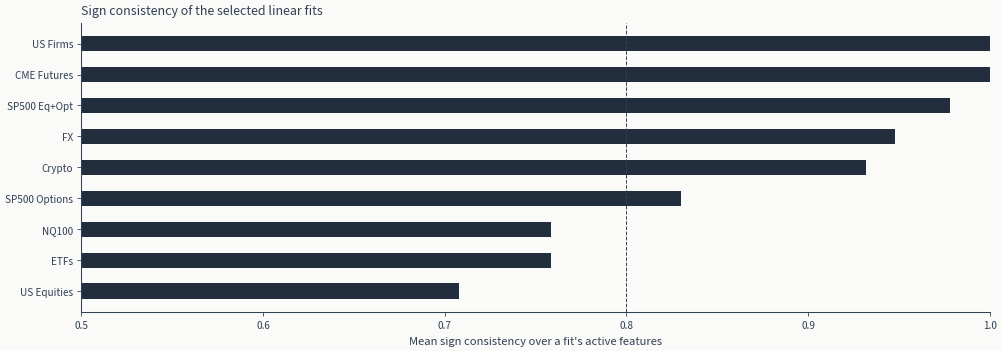

In [47]:
if sign_df.is_empty():
    display(
        Markdown(
            "No chart: no selected linear fit in this run log has stored fold models, so "
            "there are no coefficients to count signs over."
        )
    )
else:
    fig, ax = plt.subplots(figsize=(10, 3.5))
    plot_sign = sign_df.sort("mean_consistency", descending=True)
    y = np.arange(plot_sign.height)
    ax.barh(
        y,
        plot_sign["mean_consistency"].to_numpy(),
        color=COLORS["blue"],
        alpha=0.9,
        height=0.5,
    )
    ax.set_yticks(y)
    ax.set_yticklabels(plot_sign["short_name"].to_list())
    ax.invert_yaxis()
    ax.set_xlim(0.5, 1.0)
    ax.axvline(SIGN_STABLE_MIN, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
    ax.set_xlabel("Mean sign consistency over a fit's active features")
    ax.set_title("Sign consistency of the selected linear fits")
    show_with_alt(
        fig,
        "Horizontal bars of mean fold-level coefficient sign consistency, one per case "
        "study, against a dashed line at the sign-stable threshold.",
    )

In [48]:
# Counted on both paths, so the closing takeaways quote a zero rather than an absent name.
stable_sign_count = sign_df.filter(pl.col("mean_consistency") >= SIGN_STABLE_MIN).height
if sign_df.is_empty():
    display(
        Markdown(
            "No selected linear fit has stored fold models in this run log, so sign "
            "consistency cannot be measured here. The diagnostic reads the coefficients out "
            "of the per-fold models the training pipeline saves, which a run log holding "
            "only prediction sets does not carry."
        )
    )
else:
    sign_leader = sign_df.row(0, named=True)
    display(
        Markdown(
            f"Mean sign consistency reaches {SIGN_STABLE_MIN:.1f} in **{stable_sign_count} of "
            f"{sign_df.height}** selected fits, taken over the features each fit leaves "
            f"non-zero. **{sign_leader['short_name']}** is highest at "
            f"{sign_leader['mean_consistency']:.2f}. Sign stability and predictive ranking are "
            "different diagnostics: a stable coefficient direction does not by itself establish "
            "a nonzero out-of-sample IC."
        )
    )

Mean sign consistency reaches 0.8 in **6 of 9** selected fits, taken over the features each fit leaves non-zero. **US Firms** is highest at 1.00. Sign stability and predictive ranking are different diagnostics: a stable coefficient direction does not by itself establish a nonzero out-of-sample IC.

### 6b. Lasso sparsity

Lasso drives coefficients exactly to zero. The fraction of zero
coefficients per case study summarizes how aggressively Lasso prunes
features at the highest-IC $\alpha$ for the Lasso family.

In [49]:
sparsity_rows = []
for cs in CASE_STUDY_IDS:
    label = PRIMARY_LABELS.get(cs)
    if label is None:
        continue
    lasso_metrics = load_complete_metrics(cs, label=label).filter(
        pl.col("config_name").str.starts_with("lasso")
    )
    if lasso_metrics.is_empty():
        continue
    lasso_selected = select_unique_best(lasso_metrics, ["label"]).row(0, named=True)
    lasso_config = lasso_selected["config_name"]
    lasso = load_coefficients(cs, lasso_selected["training_hash"], lasso_config)
    if lasso is None:
        continue
    n_total = lasso.height
    n_zero = lasso.filter(pl.col("coefficient").abs() <= ZERO_TOL).height
    always_zero = (
        lasso.group_by("feature")
        .agg(all_zero=(pl.col("coefficient").abs() <= ZERO_TOL).all())
        .filter(pl.col("all_zero"))
        .height
    )
    n_features = lasso["feature"].n_unique()
    sparsity_rows.append(
        {
            "short_name": SHORT_NAMES[cs],
            "config_name": lasso_config,
            "n_features": n_features,
            "zero_fraction": round(n_zero / n_total, 3),
            "features_always_zero": always_zero,
            "pct_always_zero": round(always_zero / n_features * 100, 1),
        }
    )

In [50]:
sparsity_df = pl.DataFrame(
    sparsity_rows,
    schema={
        "short_name": pl.Utf8,
        "config_name": pl.Utf8,
        "n_features": pl.Int64,
        "zero_fraction": pl.Float64,
        "features_always_zero": pl.Int64,
        "pct_always_zero": pl.Float64,
    },
)
sparsity_df = sparsity_df.sort("zero_fraction", descending=True)
print("Lasso sparsity per case study (at the highest-IC Lasso $\\alpha$):")
sparsity_df

Lasso sparsity per case study (at the highest-IC Lasso $\alpha$):


short_name,config_name,n_features,zero_fraction,features_always_zero,pct_always_zero
str,str,i64,f64,i64,f64
"""SP500 Options""","""lasso_f0.85""",52,0.971,49,94.2
"""US Firms""","""lasso_f0.85""",57,0.965,52,91.2
"""CME Futures""","""lasso_f0.5""",69,0.957,61,88.4
"""FX""","""lasso_f0.2""",63,0.764,18,28.6
"""SP500 Eq+Opt""","""lasso_f0.2""",48,0.708,25,52.1
"""ETFs""","""lasso_f0.08""",71,0.66,17,23.9
"""Crypto""","""lasso_f0.015""",44,0.25,6,13.6


In [51]:
if sparsity_df.is_empty():
    display(
        Markdown(
            "No case study in this run log pairs a complete Lasso result on its primary label "
            "with a stored coefficient artifact, so there is nothing to compare here. Sparsity "
            "is read off the coefficients themselves, not off any metric the registry holds."
        )
    )
else:
    sparsest = sparsity_df.row(0, named=True)
    display(
        Markdown(
            f"Complete highest-IC Lasso coefficient artifacts are available for "
            f"**{sparsity_df.height}** case studies. **{sparsest['short_name']}** is sparsest: "
            f"{sparsest['zero_fraction']:.1%} of coefficient-by-fold cells are zero, while "
            f"{sparsest['pct_always_zero']:.1f}% of features are zero in every fold. This "
            "comparison uses one selected Lasso configuration per case study rather than "
            "pooling all alphas."
        )
    )

Complete highest-IC Lasso coefficient artifacts are available for **7** case studies. **SP500 Options** is sparsest: 97.1% of coefficient-by-fold cells are zero, while 94.2% of features are zero in every fold. This comparison uses one selected Lasso configuration per case study rather than pooling all alphas.

### 6c. Top-N feature overlap across case studies

Are the same features driving the linear signal across case studies, or does
each case study have its own world? For each case study's highest-IC linear
configuration on the primary label, we rank features by mean absolute fold
coefficient and take the leading `TOP_N`, then measure the pairwise Jaccard
overlap of those sets.

A low overlap has two explanations and the matrix alone cannot separate them:
the panels select different features from a library they share, or their
libraries barely overlap to begin with. The summary under the heatmap reports
how many feature names the most similar pair of panels has in common, which is
what tells the two apart.

In [52]:
TOP_N = 10
top_features: dict[str, set[str]] = {}
# The library each fit had to choose from, so the overlap below can be read against how
# many names the two panels share at all.
panel_features: dict[str, set[str]] = {}
for row in rank1.iter_rows(named=True):
    cs = row["case_study"]
    cfg = row["config_name"]
    coef_df = load_coefficients(cs, row["training_hash"], cfg)
    if coef_df is None:
        continue
    coefs = coef_df.filter(pl.col("config_name") == cfg)
    if coefs.is_empty():
        continue
    feature_score = (
        coefs.group_by("feature")
        .agg(score=pl.col("coefficient").abs().mean())
        # A fit that zeroes most of its features leaves dozens of exact ties at zero, and
        # `head` would fill the list from them in whatever order the group_by returned.
        .filter(pl.col("score") > ZERO_TOL)
        .sort("score", descending=True)
        .head(TOP_N)
    )
    if feature_score.is_empty():
        continue
    top_features[row["short_name"]] = set(feature_score["feature"].to_list())
    panel_features[row["short_name"]] = set(coefs["feature"].unique().to_list())

print(f"Top-{TOP_N} feature sets collected for {len(top_features)} case studies.")

Top-10 feature sets collected for 9 case studies.


In [53]:
def jaccard(a: set, b: set) -> float:
    """Return Jaccard overlap for two nonempty feature sets."""
    if not a or not b:
        return float("nan")
    return len(a & b) / len(a | b)


cs_names = sorted(top_features.keys())
J = np.full((len(cs_names), len(cs_names)), np.nan)
for i, a in enumerate(cs_names):
    for j, b in enumerate(cs_names):
        if i == j:
            J[i, j] = 1.0
        else:
            J[i, j] = jaccard(top_features[a], top_features[b])

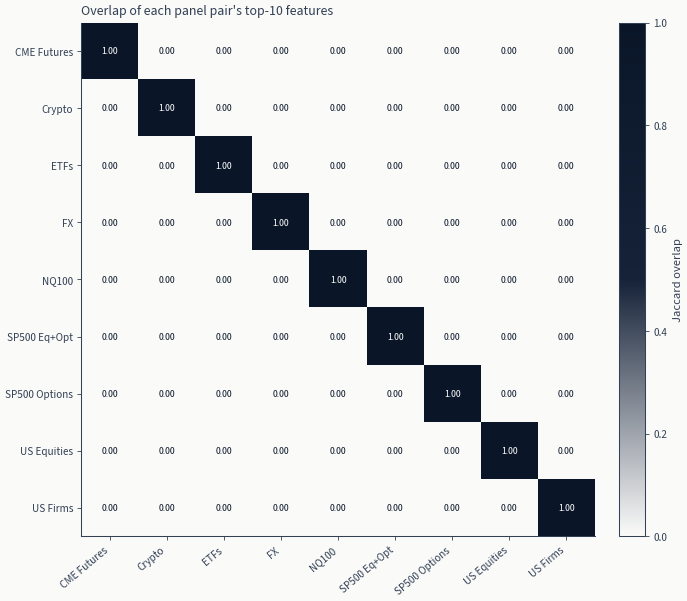

In [54]:
if not cs_names:
    display(
        Markdown(
            "No chart: no selected linear fit contributed a top feature set, so there is no "
            "overlap matrix to draw."
        )
    )
else:
    fig, ax = plt.subplots(figsize=(7, 6))
    overlap_cmap = LinearSegmentedColormap.from_list(
        "ml4t_overlap", [COLORS["bg_light"], COLORS["blue_light"], COLORS["blue"]]
    )
    im = ax.imshow(J, cmap=overlap_cmap, vmin=0, vmax=1)
    ax.set_xticks(np.arange(len(cs_names)))
    ax.set_yticks(np.arange(len(cs_names)))
    ax.set_xticklabels(cs_names, rotation=40, ha="right")
    ax.set_yticklabels(cs_names)
    for i in range(len(cs_names)):
        for j in range(len(cs_names)):
            v = J[i, j]
            if not np.isnan(v):
                ax.text(
                    j,
                    i,
                    f"{v:.2f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="white" if v > 0.5 else COLORS["blue"],
                )
    ax.set_title(f"Overlap of each panel pair's top-{TOP_N} features")
    colorbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.04)
    colorbar.set_label("Jaccard overlap")
    show_with_alt(
        fig,
        "Symmetric heatmap of the pairwise Jaccard overlap between each pair of case "
        "studies' leading coefficient features, each cell labelled with its value. The "
        "title names how many features each set holds.",
    )

In [55]:
off_diagonal = J[~np.eye(len(cs_names), dtype=bool)]
# An overlap is a statement about two panels, so it needs two of them. With one
# feature set, or none, the off-diagonal is empty and there is no largest value -
# reported as unavailable rather than as a number the matrix does not contain.
has_overlap = bool(off_diagonal.size) and bool(np.isfinite(off_diagonal).any())
max_overlap = float(np.nanmax(off_diagonal)) if has_overlap else float("nan")
overlap_phrase = (
    f"only {max_overlap:.2f}"
    if has_overlap
    else "unavailable, because fewer than two panels contributed a feature set"
)
# How many feature names the most-overlapping pair of panels has in common. A zero top-N
# overlap between panels with disjoint libraries says nothing about selection.
shared_library = [
    (len(panel_features[a] & panel_features[b]), a, b)
    for index, a in enumerate(cs_names)
    for b in cs_names[index + 1 :]
]
most_shared = max(shared_library) if shared_library else (0, "", "")
if has_overlap:
    if most_shared[0] > 0:
        _shared_pair_overlap = jaccard(top_features[most_shared[1]], top_features[most_shared[2]])
        _library_note = (
            f"The two panels with the most library in common are **{most_shared[1]}** and "
            f"**{most_shared[2]}**, sharing {most_shared[0]} feature names; their leading "
            f"sets overlap at {_shared_pair_overlap:.2f}. Read that number rather than the "
            "maximum above when asking whether the panels select differently: two panels "
            "with no shared library cannot agree on a leading feature whatever their fits "
            "do."
        )
    else:
        _library_note = (
            "No two panels share a feature name here, so this overlap is a statement about "
            "the libraries rather than about what each fit selected from them."
        )
    display(
        Markdown(
            f"The largest off-diagonal top-{TOP_N} Jaccard overlap is **{max_overlap:.2f}**. "
            + _library_note
        )
    )
else:
    display(
        Markdown(
            f"Fewer than two case studies contributed a top-{TOP_N} feature set here, so there "
            "is no cross-panel overlap to report. The comparison needs two selected fits with "
            "stored coefficients."
        )
    )

The largest off-diagonal top-10 Jaccard overlap is **0.00**. The two panels with the most library in common are **CME Futures** and **US Equities**, sharing 24 feature names; their leading sets overlap at 0.00. Read that number rather than the maximum above when asking whether the panels select differently: two panels with no shared library cannot agree on a leading feature whatever their fits do.

## 7. Cross-CS Takeaways

**Next**: Ch12 extends the comparison with gradient boosting and
tabular deep learning; Ch13 with temporal deep learning.

Panel-specificity is a claim about two panels disagreeing, so it cannot be made from
one. Where the overlap could not be computed, the closing bullet reports the sign
consistency it does have and says the comparison is missing, rather than asserting the
conclusion the missing half was there to support.

In [56]:
coefficient_takeaway = (
    f"**Coefficient behavior is panel-specific:** {stable_sign_count} selected fits clear "
    f"{SIGN_STABLE_MIN:.1f} mean sign consistency, and the largest top-{TOP_N} cross-panel "
    f"feature overlap is "
    f"{overlap_phrase}."
    if has_overlap
    else f"**Coefficient behavior across panels is not established here:** "
    f"{stable_sign_count} selected fits clear {SIGN_STABLE_MIN:.1f} mean sign consistency, "
    f"but the top-{TOP_N} "
    f"cross-panel feature overlap is {overlap_phrase}, so whether the panels draw on "
    "different features is not something this run can say."
)

In [57]:
display(
    Markdown(
        f"- **Primary-label evidence is selective:** {significant.height} of {rank1.height} "
        "complete linear results have HAC intervals that exclude zero.\n"
        f"- **Ridge is a durable baseline:** it matches or exceeds OLS in {ridge_wins} of "
        f"{ridge_ols_wide.height} comparable panels, while most differences remain small relative "
        "to uncertainty.\n"
        f"- **Fold stability needs context:** {icir_leader['short_name']} leads ICIR, but its "
        f"estimate uses only {icir_leader['n_folds']} folds.\n"
        f"- **Ranking and direction are not symmetric:** regression-score mean daily AUC stays "
        f"within {max_auc_gap:.3f} of chance in the tested pairs.\n"
        f"- {coefficient_takeaway}"
    )
)

- **Primary-label evidence is selective:** 2 of 9 complete linear results have HAC intervals that exclude zero.
- **Ridge is a durable baseline:** it matches or exceeds OLS in 9 of 9 comparable panels, while most differences remain small relative to uncertainty.
- **Fold stability needs context:** NQ100 leads ICIR, but its estimate uses only 2 folds.
- **Ranking and direction are not symmetric:** regression-score mean daily AUC stays within 0.007 of chance in the tested pairs.
- **Coefficient behavior is panel-specific:** 6 selected fits clear 0.8 mean sign consistency, and the largest top-10 cross-panel feature overlap is only 0.00.